In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATASET_PATH = "/content/drive/MyDrive/audio_speech_actors_01-24"

In [3]:
import os

print("Exists:", os.path.exists(DATASET_PATH))
print("Actor folders:", len(os.listdir(DATASET_PATH)))
print(os.listdir(DATASET_PATH)[:5])

Exists: True
Actor folders: 24
['Actor_24', 'Actor_20', 'Actor_23', 'Actor_22', 'Actor_21']


In [4]:
import librosa

sample_file = os.path.join(
    DATASET_PATH,
    "Actor_01",
    os.listdir(os.path.join(DATASET_PATH, "Actor_01"))[0]
)

audio, sr = librosa.load(sample_file, sr=None)

print("File:", sample_file)
print("Sample Rate:", sr)
print("Duration:", len(audio) / sr, "seconds")

File: /content/drive/MyDrive/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-02-01.wav
Sample Rate: 48000
Duration: 3.3366666666666664 seconds


In [5]:
import librosa
import numpy as np

mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("MFCC Shape:", mfccs.shape)

mfccs_mean = np.mean(mfccs.T, axis=0)

print("Feature Vector Shape:", mfccs_mean.shape)
print(mfccs_mean)

MFCC Shape: (13, 313)
Feature Vector Shape: (13,)
[-719.1283      70.20157      1.1683981   13.122543     7.836951
   14.411289    -4.111359     4.4689717   -3.5393672   -3.6586087
   -7.648503    -1.4770778    3.031821 ]


In [6]:
import os
import librosa
import numpy as np
import pandas as pd

In [7]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [8]:
X = []
y = []

count = 0

for actor_folder in os.listdir(DATASET_PATH):

    actor_path = os.path.join(DATASET_PATH, actor_folder)

    if not os.path.isdir(actor_path):
        continue

    for file_name in os.listdir(actor_path):

        if not file_name.endswith(".wav"):
            continue

        file_path = os.path.join(actor_path, file_name)

        audio, sr = librosa.load(file_path, sr=None)

        mfccs = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )

        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std = np.std(mfccs, axis=1)

        mfcc_features = np.hstack([mfcc_mean, mfcc_std])

        emotion_code = file_name.split("-")[2]
        emotion_label = emotion_map[emotion_code]

        X.append(mfcc_features)
        y.append(emotion_label)

        count += 1

        if count % 100 == 0:
            print(f"Processed {count} files")

Processed 100 files
Processed 200 files
Processed 300 files
Processed 400 files
Processed 500 files
Processed 600 files
Processed 700 files
Processed 800 files
Processed 900 files
Processed 1000 files
Processed 1100 files
Processed 1200 files
Processed 1300 files
Processed 1400 files


In [9]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1440, 80)
y shape: (1440,)


In [10]:
pd.Series(y).value_counts()

,count
happy,192
calm,192
sad,192
fearful,192
surprised,192
angry,192
disgust,192
neutral,96


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1152
Testing samples: 288


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, class_weight='balanced'))])

In [13]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7708333333333334


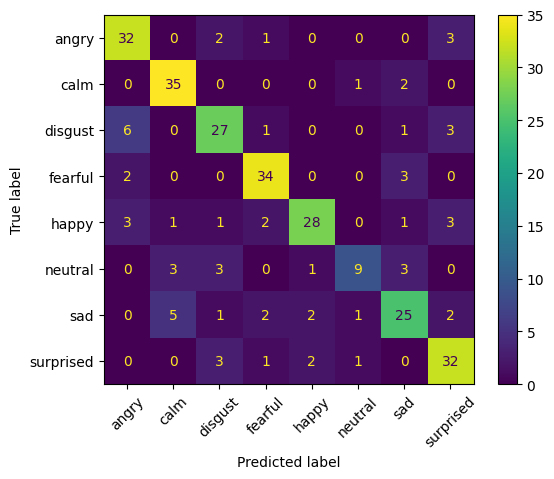

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.74      0.84      0.79        38
        calm       0.80      0.92      0.85        38
     disgust       0.73      0.71      0.72        38
     fearful       0.83      0.87      0.85        39
       happy       0.85      0.72      0.78        39
     neutral       0.75      0.47      0.58        19
         sad       0.71      0.66      0.68        38
   surprised       0.74      0.82      0.78        39

    accuracy                           0.77       288
   macro avg       0.77      0.75      0.75       288
weighted avg       0.77      0.77      0.77       288



In [16]:
import joblib

joblib.dump(model, "emotion_recognition_model.pkl")

['emotion_recognition_model.pkl']

In [17]:
model = joblib.load("emotion_recognition_model.pkl")

In [18]:
import joblib

joblib.dump(
    model,
    "/content/drive/MyDrive/emotion_recognition_model.pkl"
)

['/content/drive/MyDrive/emotion_recognition_model.pkl']